In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [96]:
# AirPassengers veri setini yükleyelim
df = pd.read_csv('AirPassengers.csv')

In [97]:
print(f"\n{df.head()}")


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [98]:
# Tarih indeksini ayarlayalım
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Veri setine göz atalım
print("Veri seti özeti:")
print(f"  Gözlem sayısı: {len(df)}")
print(f"  Tarih aralığı: {df.index.min()} - {df.index.max()}")


Veri seti özeti:
  Gözlem sayısı: 144
  Tarih aralığı: 1949-01-01 00:00:00 - 1960-12-01 00:00:00


In [99]:
# Index'i sıfırlayın ve sütun adlarını değiştirin
df.reset_index(inplace=True)
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])

In [100]:
# 2. Train (Eğitim) ve Test (Doğrulama) Ayrımı
# Veri setimiz 1960-12'de bitiyor. Son 12 ayı kesip alıyoruz.
train_data = df.iloc[:-12]  # 1949-01'den 1959-12'ye kadar (Model burayı görecek)
test_data = df.iloc[-12:]   # 1960-01'den 1960-12'ye kadar (Model burayı GÖRMEYECEK)

print(f"Eğitim Verisi Bitiş: {train_data['ds'].max()}")
print(f"Test Verisi Başlangıç: {test_data['ds'].min()}")

Eğitim Verisi Bitiş: 1959-12-01 00:00:00
Test Verisi Başlangıç: 1960-01-01 00:00:00


In [101]:
print(f"\n{df.tail()}")


            ds    y
139 1960-08-01  606
140 1960-09-01  508
141 1960-10-01  461
142 1960-11-01  390
143 1960-12-01  432


In [102]:
print(f"\nTemel istatistikler:\n{df.describe()}")


Temel istatistikler:
                        ds           y
count                  144  144.000000
mean   1954-12-16 05:00:00  280.298611
min    1949-01-01 00:00:00  104.000000
25%    1951-12-24 06:00:00  180.000000
50%    1954-12-16 12:00:00  265.500000
75%    1957-12-08 18:00:00  360.500000
max    1960-12-01 00:00:00  622.000000
std                    NaN  119.966317


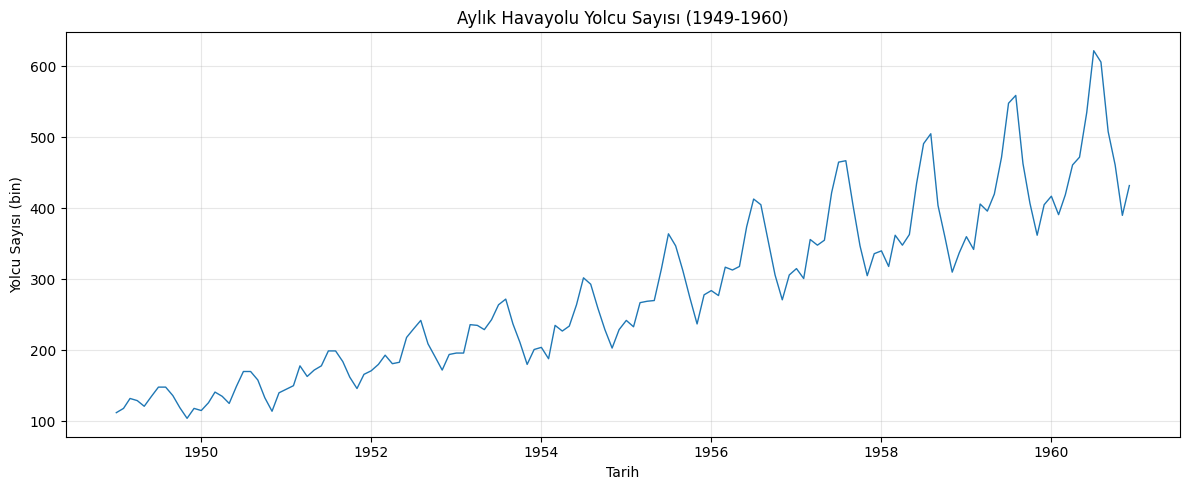

In [103]:
# Seriyi çizdirelim
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], linewidth=1)
plt.title('Aylık Havayolu Yolcu Sayısı (1949-1960)')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

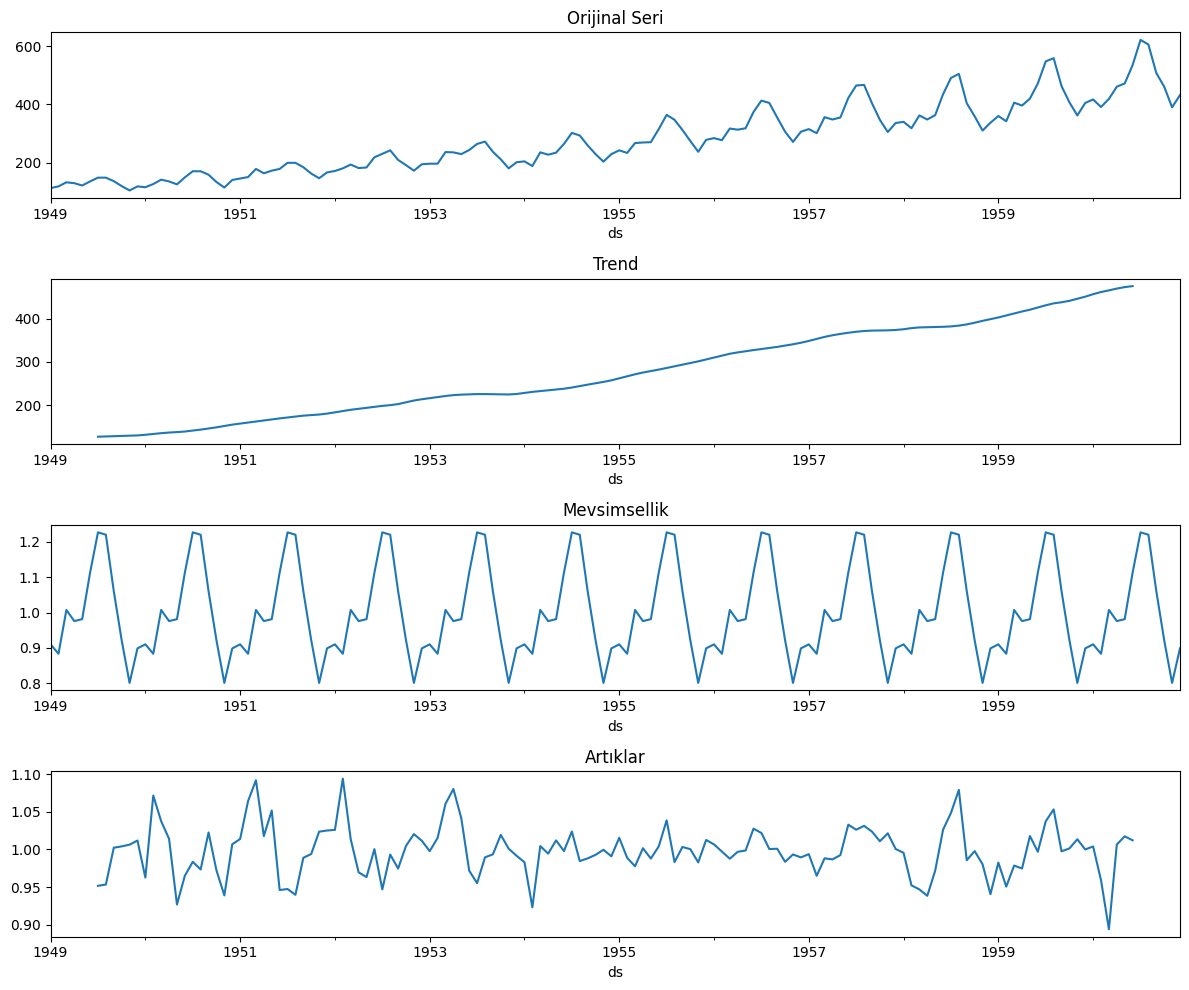

In [104]:

# Bileşenlere ayırma
# Index'i tarih olarak ayarlayın
df_with_index = df.set_index('ds')
decomposition = seasonal_decompose(df_with_index['y'], model='multiplicative',period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Orijinal Seri')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Mevsimsellik')
decomposition.resid.plot(ax=axes[3], title='Artıklar')
plt.tight_layout()
plt.show()

In [105]:
def adf_test(series, name=""):
    """
    ADF testi uygular ve sonuçları yorumlar.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"\n{name} - ADF Testi Sonuçları:")
    print(f"  Test İstatistiği: {result[0]:.4f}")
    print(f"  p-değeri: {result[1]:.4f}")
    print(f"  Kritik Değerler:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print("  → Seri durağan (H0 reddedildi)")
    else:
        print("  → Seri durağan değil (H0 reddedilemedi)")
    
    return result[1]

# Test edelim
adf_test(df['y'], "Orijinal Seri")


Orijinal Seri - ADF Testi Sonuçları:
  Test İstatistiği: 0.8154
  p-değeri: 0.9919
  Kritik Değerler:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788
  → Seri durağan değil (H0 reddedilemedi)


0.9918802434376409

In [106]:
# 2. Train (Eğitim) ve Test (Doğrulama) Ayrımı
# Veri setimiz 1960-12'de bitiyor. Son 12 ayı kesip alıyoruz.
train_data = df.iloc[:-12]  # 1949-01'den 1959-12'ye kadar (Model burayı görecek)
test_data = df.iloc[-12:]   # 1960-01'den 1960-12'ye kadar (Model burayı GÖRMEYECEK)

print(f"Eğitim Verisi Bitiş: {train_data['ds'].max()}")
print(f"Test Verisi Başlangıç: {test_data['ds'].min()}")

Eğitim Verisi Bitiş: 1959-12-01 00:00:00
Test Verisi Başlangıç: 1960-01-01 00:00:00


In [107]:
# 3. Modeli Kurma ve Eğitme
# Çarpımsal (multiplicative) modu unutmuyoruz, verinin doğası bu.
model = Prophet(seasonality_mode='multiplicative',
    yearly_seasonality=True,
    daily_seasonality=False,
    weekly_seasonality=False)
model.fit(train_data)


22:58:59 - cmdstanpy - INFO - Chain [1] start processing
22:58:59 - cmdstanpy - INFO - Chain [1] done processing


In [108]:
# 4. Tahmin yapalım (Sadece Test Dönemi - 1960)
forecast = model.predict(test_data[['ds']])

# 5. Performansı ölçelim
# Değerleri numpy array'e çevirmeden doğrudan Series üzerinden hesaplıyoruz
rmse = np.sqrt(mean_squared_error(test_data['y'], forecast['yhat']))
mae = mean_absolute_error(test_data['y'], forecast['yhat'])


print(f"1960 Performansı -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# (İsteğe bağlı: Referans koddaki gibi gelecek tahminlerini de görmek istersen)
print("--- Tahmin Detayları ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(12))

1960 Performansı -> RMSE: 25.82, MAE: 21.90
--- Tahmin Detayları ---
           ds        yhat  yhat_lower  yhat_upper
0  1960-01-01  402.445018  389.799696  414.533840
1  1960-02-01  392.948490  379.581245  405.700818
2  1960-03-01  455.584216  442.802852  468.017759
3  1960-04-01  441.584031  429.295170  454.465240
4  1960-05-01  442.918309  431.210610  455.790237
5  1960-06-01  520.585208  507.672816  533.375759
6  1960-07-01  569.037583  556.496995  581.606941
7  1960-08-01  573.233300  560.893201  586.122358
8  1960-09-01  496.525013  484.141927  508.749224
9  1960-10-01  433.306270  421.022480  445.721665
10 1960-11-01  379.730999  367.287458  392.963980
11 1960-12-01  420.384456  408.058558  434.178882


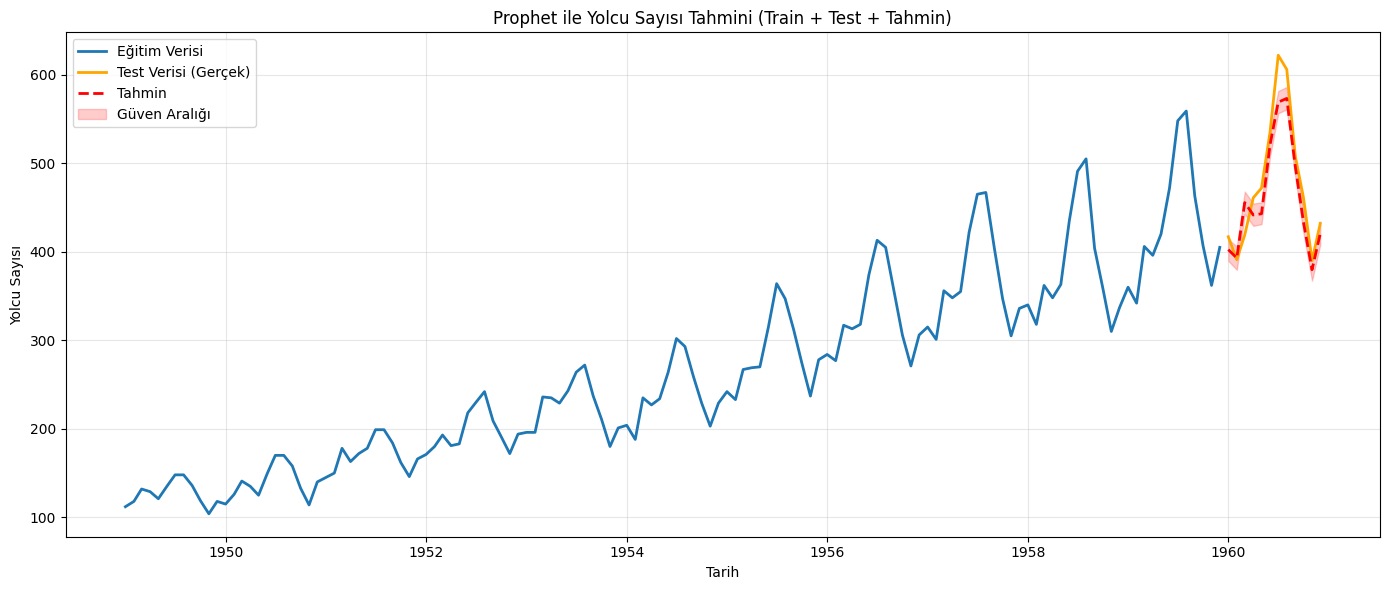

In [110]:
# Tahmin grafiği - Train ve Test verisi ile birlikte
plt.figure(figsize=(14, 6))

# Eğitim verisi
plt.plot(train_data['ds'], train_data['y'], label='Eğitim Verisi', linewidth=2)

# Test verisi
plt.plot(test_data['ds'], test_data['y'], label='Test Verisi (Gerçek)', linewidth=2, color='orange')

# Tahmin
plt.plot(forecast['ds'], forecast['yhat'], label='Tahmin', linewidth=2, linestyle='--', color='red')

# Güven aralığı
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 alpha=0.2, color='red', label='Güven Aralığı')

plt.title('Prophet ile Yolcu Sayısı Tahmini (Train + Test + Tahmin)')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

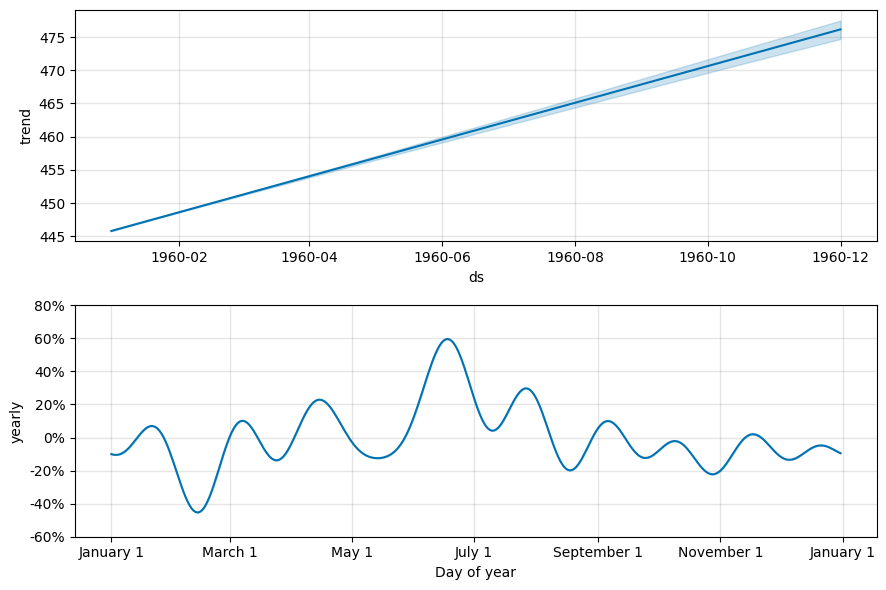

In [111]:
# Bileşen grafikleri
fig2 = model.plot_components(forecast)
plt.show()